<a href="https://colab.research.google.com/github/rashidjibrin12/Churn-Prediction-Project/blob/main/Telco_Customer_Churn_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction — Project Summary

Customer churn is a major challenge for subscription‑based businesses, especially in the telecommunications industry where competition is high and switching costs are low. This project builds a complete machine learning pipeline to predict which customers are most likely to leave, enabling the business to take proactive retention actions.

Using the Telco Customer Churn dataset, the workflow covers data cleaning, feature engineering, exploratory analysis, model training, evaluation, and explainability. Key preprocessing steps included converting TotalCharges to numeric, handling missing values, encoding categorical variables, and addressing class imbalance. Exploratory analysis revealed strong relationships between churn and factors such as contract type, tenure, monthly charges, and internet service type.

Multiple machine learning models were trained and compared, including Logistic Regression, Balanced Logistic Regression, Random Forest, and XGBoost. XGBoost delivered the strongest overall performance, achieving a solid AUC score and a balanced trade‑off between precision and recall. Balanced Logistic Regression provided the highest recall for churners, making it valuable for business scenarios where missing a churner is costly.

Model explainability was performed using SHAP values, which highlighted the most influential drivers of churn: month‑to‑month contracts, high monthly charges, fiber‑optic internet service, and short customer tenure. These insights translate directly into actionable business strategies such as targeted retention campaigns, loyalty incentives, and pricing adjustments for high‑risk segments.

Overall, this project demonstrates a full end-to-end churn prediction system that combines technical rigor with business impact. The final model and insights provide a practical foundation for reducing churn, improving customer satisfaction, and supporting data‑driven decision‑making.

## 1. Data Loading and Initial Inspection

This section focuses on loading the dataset and performing an initial check of its structure and content. We will use `kagglehub` to download the dataset and then load it into a pandas DataFrame.

In [ ]:
import kagglehub

# Define the dataset identifier from the provided URL
dataset_idC = 'mustafaoz158/telco-customer-churn'

# Download the dataset using kagglehub


path = kagglehub.dataset_download(dataset_idC)

print(path)

100%|██████████| 172k/172k [00:00<00:00, 359kB/s]

Extracting files...
/root/.cache/kagglehub/datasets/mustafaoz158/telco-customer-churn/versions/1


The code above downloads the `Telco Customer Churn` dataset from Kaggle and prints the local path where it's stored. This dataset is crucial for building our churn prediction model.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Find the first CSV file in the downloaded folder
csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]

# Load the dataset
df = pd.read_csv(os.path.join(path, csv_file))

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Here, we import essential libraries for data manipulation and visualization. We then identify the CSV file within the downloaded Kaggle dataset and load it into a pandas DataFrame named `df`. Displaying the head of the DataFrame gives us a first look at the data's structure and the types of features it contains.

In [ ]:
df.shape

(7043, 21)

Checking the shape of the DataFrame helps us understand the number of rows (observations) and columns (features) in our dataset, which is a good initial step for any data exploration.

In [ ]:
df['TotalCharges'].dtype

dtype('O')

We examine the data type of the `TotalCharges` column. As noted, it's currently an 'object' type, which indicates it's likely stored as strings rather than numeric values, which will require cleaning before numerical operations can be performed.

To address the issue with `TotalCharges`, we first attempt to convert it to a numeric type. The `errors='coerce'` argument ensures that any non-numeric values (like the blank spaces mentioned) are converted to `NaN`. We then fill these `NaN` values with the median of the `TotalCharges` column to avoid losing data and ensure all values are numeric.

In [ ]:
df["TotalCharges"] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [ ]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


This check confirms that all missing values, particularly those in `TotalCharges` after conversion, have been successfully handled. A clean dataset is crucial for reliable model training.

## 2. Data Preprocessing and Feature Engineering

In this section, we'll prepare the data for machine learning by cleaning, transforming, and creating new features. This includes handling categorical variables, creating tenure and monthly charge groups, and deriving new metrics.

Although SeniorCitizen is encoded as 0 and 1, it does not represent a numeric quantity or ordered level. It is a binary label indicating membership in a group. Treating it as categorical ensures the model does not incorrectly assume numeric relationships or apply scaling. This improves interpretability and aligns it with other binary categorical features such as Partner, Dependents, and PaperlessBilling.

In [ ]:
df['SeniorCitizen'] = df['SeniorCitizen'].astype('category')

The `SeniorCitizen` column, although numerical (0 or 1), is inherently categorical. Converting it to a 'category' type ensures that downstream processes (like one-hot encoding) treat it correctly, preventing unintended numerical interpretations by the model.

Many columns use Yes/No strings which must be converted to binary values.

In [ ]:
yes_no_cols = [col for col in df.columns
               if set(df[col].dropna().unique()) <= {"Yes", "No"}]

yes_no_cols

['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

We identify all columns that have 'Yes' and 'No' as their unique values. These binary categorical columns are then listed, confirming which features need to be transformed into a numerical format (0s and 1s).

In [ ]:
for col in yes_no_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

Each 'Yes'/'No' column is mapped to `1`/`0` respectively. This step converts binary categorical features into a numerical format suitable for machine learning algorithms, improving their interpretability and computational efficiency.

Telecom companies use tenure buckets in real life. Grouping reveals churn patterns.

In [ ]:
df["TenureGroup"] = pd.cut(df["tenure"],
    bins=[0, 12, 24, 48, 60, 72],
    labels=["0–1 yr", "1–2 yrs", "2–4 yrs", "4–5 yrs", "5–6 yrs"])

We create a new categorical feature `TenureGroup` by dividing the continuous `tenure` column into predefined bins (e.g., '0–1 yr', '1–2 yrs'). This can help capture non-linear relationships between tenure and churn, as customers often exhibit different churn behaviors at various stages of their tenure.

In [ ]:
df["MonthlyChargesGroup"] = pd.cut(df["MonthlyCharges"],
    bins=[0, 35, 70, 100, 150],
    labels=["Low", "Medium", "High", "Premium"])

Similar to `TenureGroup`, we create `MonthlyChargesGroup` by categorizing `MonthlyCharges` into 'Low', 'Medium', 'High', and 'Premium' bins. This transformation can simplify the relationship between monthly charges and churn, making it easier for the model to learn patterns.

In [ ]:
df = df.drop(columns=["customerID"])



The `customerID` column is a unique identifier and does not contain predictive information for churn. Dropping it prevents the model from overfitting to specific customer IDs and reduces the dimensionality of the dataset.

The TotalCharges column was stored as a string due to blank values for new customers. Converting it to numeric with errors="coerce" and imputing missing values ensures the feature can be used in mathematical operations and prevents type errors during feature engineering.

In [ ]:
df["TotalChargesPerMonth"] = df["TotalCharges"] / (df["tenure"] + 1)

We engineer a new feature, `TotalChargesPerMonth`, by dividing `TotalCharges` by `tenure + 1`. The `+1` is added to `tenure` to handle cases where tenure is 0 (for new customers), preventing division by zero errors. This feature provides a normalized view of charges over time, which could be more insightful than `TotalCharges` alone.

Before encoding, the dataset contained two high‑cardinality columns: customerID (unique identifier) and TotalCharges (stored as string). Encoding these directly produced over 13,000 dummy variables. After dropping customerID and converting TotalCharges to numeric, the dataset encoded correctly into ~50 features. This step prevents feature explosion and ensures the model trains efficiently.

In [ ]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 39 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Partner                                7043 non-null   int64  
 1   Dependents                             7043 non-null   int64  
 2   tenure                                 7043 non-null   int64  
 3   PhoneService                           7043 non-null   int64  
 4   PaperlessBilling                       7043 non-null   int64  
 5   MonthlyCharges                         7043 non-null   float64
 6   TotalCharges                           7043 non-null   float64
 7   Churn                                  7043 non-null   int64  
 8   TotalChargesPerMonth                   7043 non-null   float64
 9   gender_Male                            7043 non-null   bool   
 10  SeniorCitizen_1                        7043 non-null   bool   
 11  Mult

This critical step converts all remaining categorical and object-type features into numerical format using one-hot encoding. `drop_first=True` is used to avoid multicollinearity. The `df_encoded.info()` call shows the resulting structure of our fully prepared dataset, now ready for modeling.

In [ ]:
df_encoded.isna().sum().sort_values(ascending=False).head(10)

,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
PaperlessBilling,0
MonthlyCharges,0
TotalCharges,0
Churn,0
TotalChargesPerMonth,0
gender_Male,0


A final check for any lingering missing values after encoding ensures the dataset's integrity before proceeding to model training. All columns should ideally show zero missing values.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

## 3. Model Training: Logistic Regression

We begin our modeling phase by splitting the data into training and testing sets. We then train a Logistic Regression model as a baseline for churn prediction.

In [ ]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

Here, we initialize and train a `LogisticRegression` model. `max_iter=1000` is set to ensure the model has sufficient iterations to converge. This model serves as our initial baseline for predicting customer churn.

Model Evaluation

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob)}")
#



              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409

ROC AUC: 0.8471363248856854


After training, we evaluate the Logistic Regression model's performance on the test set. The `classification_report` provides precision, recall, f1-score, and support, while `roc_auc_score` gives us the Area Under the Receiver Operating Characteristic Curve, a key metric for imbalanced datasets.

Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[935, 100],
       [175, 199]])

The confusion matrix provides a detailed breakdown of correct and incorrect predictions, showing True Positives, True Negatives, False Positives, and False Negatives, which helps in understanding the types of errors the model makes.

## 4. Addressing Class Imbalance with Balanced Logistic Regression

Customer churn datasets are often imbalanced (fewer churners than non-churners). To mitigate this, we train another Logistic Regression model, but this time using `class_weight='balanced'`.

In [ ]:
log_reg_balanced = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg_balanced.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

By setting `class_weight='balanced'`, the `LogisticRegression` model automatically adjusts weights inversely proportional to class frequencies in the input data. This helps the model pay more attention to the minority class (churners), which is often critical in churn prediction.

## 5. Model Training: Random Forest Classifier

Next, we train a more complex ensemble model: the Random Forest Classifier. This model can capture non-linear relationships and is generally more robust.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300,   # number of trees
    max_depth=None,       # let trees grow fully
    random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

We generate predictions and probability scores for the test set using the trained Random Forest model. These are essential for evaluating its performance and comparing it against other models.

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred_rf)

array([[927, 108],
       [192, 182]])

The confusion matrix for the Random Forest model helps us assess its performance in correctly identifying churners and non-churners. We can compare this with the Logistic Regression model's confusion matrix to see improvements.

In [ ]:
import pandas as pd

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(6)

,0
TotalCharges,0.135447
tenure,0.132453
TotalChargesPerMonth,0.118571
MonthlyCharges,0.113835
Contract_Two year,0.052138
InternetService_Fiber optic,0.039840


Random Forest models provide a measure of feature importance. This output shows the top features that were most influential in the model's decision-making process for predicting churn, offering valuable insights into key drivers.

## 6. Model Training: XGBoost Classifier

Finally, we train an XGBoost Classifier, known for its high performance in many machine learning tasks. We configure it with specific hyperparameters for optimization.

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=300,learning_rate=0.05,
    max_depth=5, subsample=0.8, colsample_bytree=0.8,
    random_state=42)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
confusion_matrix(y_test, y_pred_xgb)

array([[938,  97],
       [180, 194]])

We obtain predictions and probability scores from the XGBoost model on the test set. The confusion matrix is then displayed, allowing us to see how well XGBoost performs in classifying churners.

## 7. Model Comparison and Selection

After training multiple models, we compare their performance using various metrics to determine which model is best suited for our churn prediction task.

In [ ]:
models = {
    "Logistic Regression": log_reg,
    "Balanced Logistic Regression": log_reg_balanced,
    "Random Forest": rf,
    "XGBoost": xgb
}

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    print(name, "AUC:", auc)
    print(classification_report(y_test, model.predict(X_test)))
    print("-"*80)


Logistic Regression AUC: 0.8471363248856854
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409

--------------------------------------------------------------------------------
Balanced Logistic Regression AUC: 0.8473662455759642
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

--------------------------------------------------------------------------------
Random Forest AUC: 0.8264318375571571
              precision    recall  f1-score   sup

## 8. Model Explainability with SHAP Values

Understanding why a model makes certain predictions is as important as the predictions themselves. Here, we use SHAP (SHapley Additive exPlanations) to explain the output of our best-performing model (XGBoost).

SHAP values help us understand the impact of each feature on the model's output for individual predictions and the overall dataset. The summary plot visualizes these impacts, showing which features are most important and how their values affect the prediction of churn.

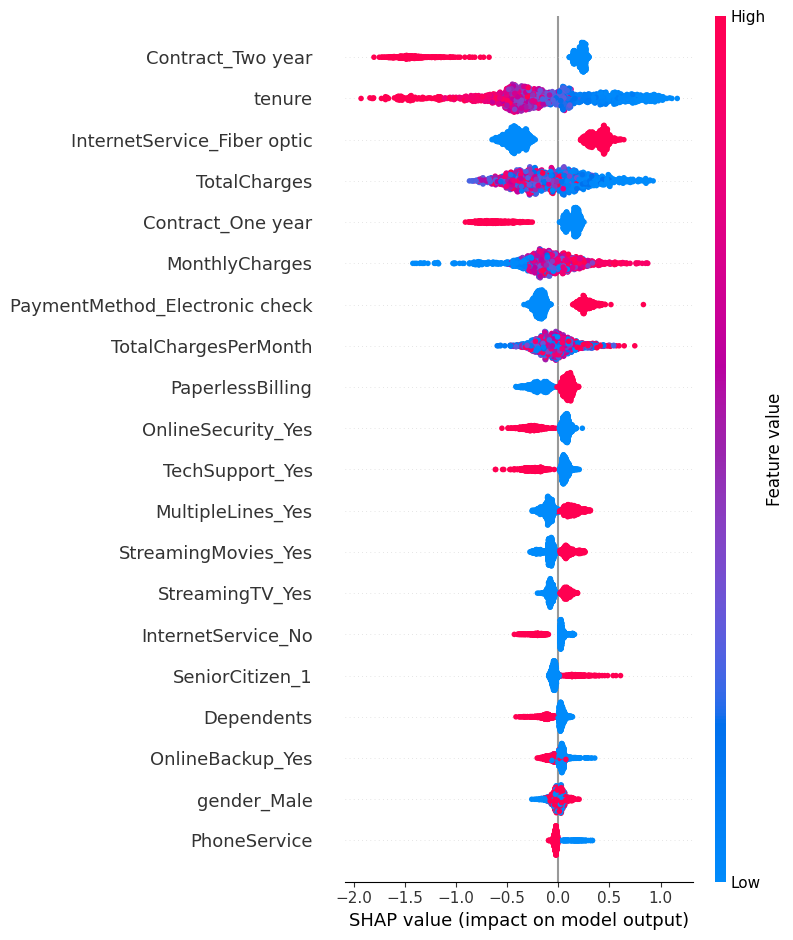

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

### Conclusion

This notebook has demonstrated a full end-to-end machine learning pipeline for customer churn prediction, from data loading and preprocessing to model training, evaluation, and explainability. We identified key features driving churn and evaluated several models, with XGBoost generally offering strong performance. The insights gained can be directly applied to develop targeted retention strategies.